# BÀI THỰC HÀNH 01. CÁC PHÉP TOÁN ĐIỂM ẢNH VÀ HIỆU CHỈNH HISTOGRAM
Trong bài thực hành này, ta sẽ tìm hiểu cách đọc ảnh xám ở dạng ma trận, vẽ biểu đồ Histogram, cân bằng điểm ảnh (Histogram Equalization), và đi sâu vào các phép toán điểm ảnh Pixel-wise cơ bản.


## 0. Cài đặt Môi trường & Hàm hỗ trợ


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_gray(img, title='Gray image', figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_multiple(images, titles=None, cols=3, figsize=(15, 5)):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.axis('off')
        if titles: plt.title(titles[i])
    plt.tight_layout()
    plt.show()


## 1. Đọc ảnh và Biểu đồ mức xám (Grayscale & Histogram)
Ta sẽ sử dụng Pure NumPy so sánh với cv2.calcHist để thấy rõ thuật toán thống kê.


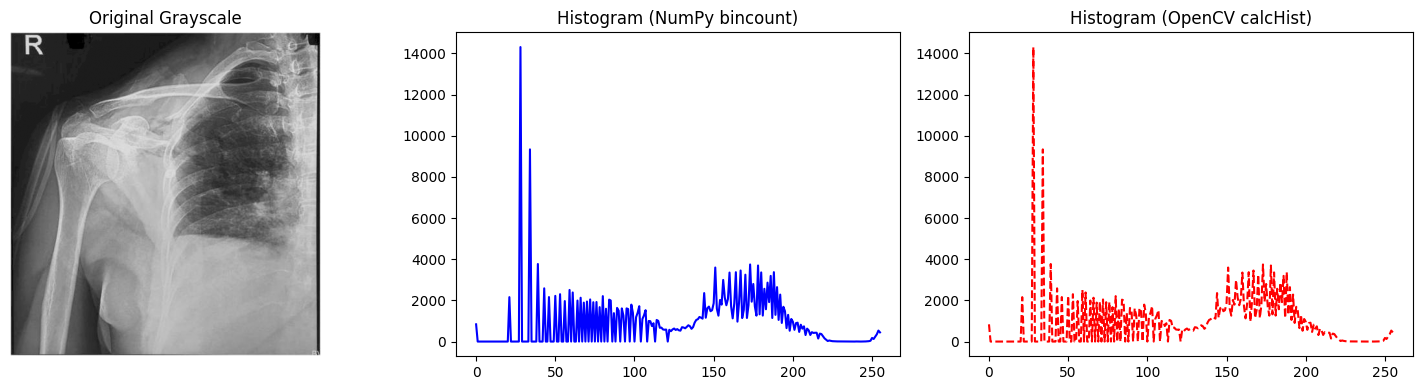

In [2]:
IMG_PATH = "../Resources/test_1_lab01.png"
img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)

if img is not None:
    # NumPy Histogram
    hist_np = np.bincount(img.ravel(), minlength=256)
    
    # OpenCV Histogram
    hist_cv = cv2.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256]).ravel()
    
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title("Original Grayscale")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.plot(hist_np, color='blue')
    plt.title("Histogram (NumPy bincount)")
    
    plt.subplot(1, 3, 3)
    plt.plot(hist_cv, color='red', linestyle='dashed')
    plt.title("Histogram (OpenCV calcHist)")
    plt.tight_layout()
    plt.show()


## 2. Cân bằng Histogram (Histogram Equalization)
Mục tiêu là dàn đều biểu đồ cường độ sáng, giúp ảnh có độ tương phản tổng thể tốt hơn.


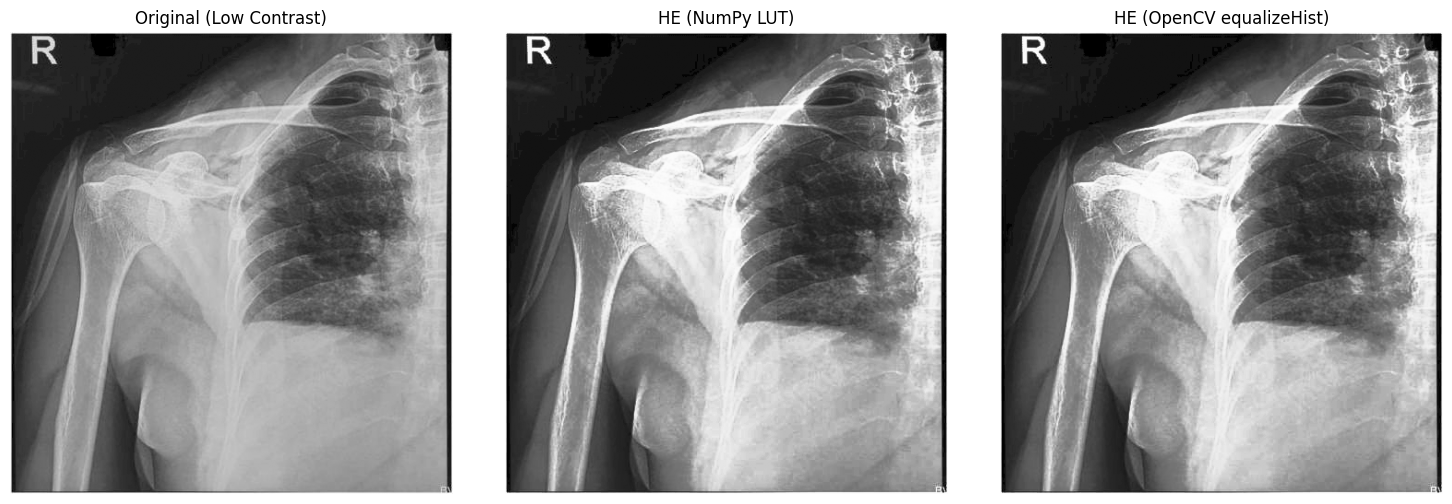

In [3]:
if img is not None:
    # ----- NumPy Global HE -----
    hist = np.bincount(img.ravel(), minlength=256)
    p = hist / hist.sum()
    cdf = np.cumsum(p)
    
    # Look-up table (LUT) mapping
    lut = np.floor(255 * cdf).astype(np.uint8)
    img_he_np = lut[img]
    
    # ----- OpenCV Global HE -----
    img_he_cv = cv2.equalizeHist(img)
    
    show_multiple([img, img_he_np, img_he_cv], 
                  ['Original (Low Contrast)', 'HE (NumPy LUT)', 'HE (OpenCV equalizeHist)'])


## 3. Các phép biến đổi điểm ảnh (Pixel-wise Transforms)


Tổng hợp các biến đổi Pixel-wise:


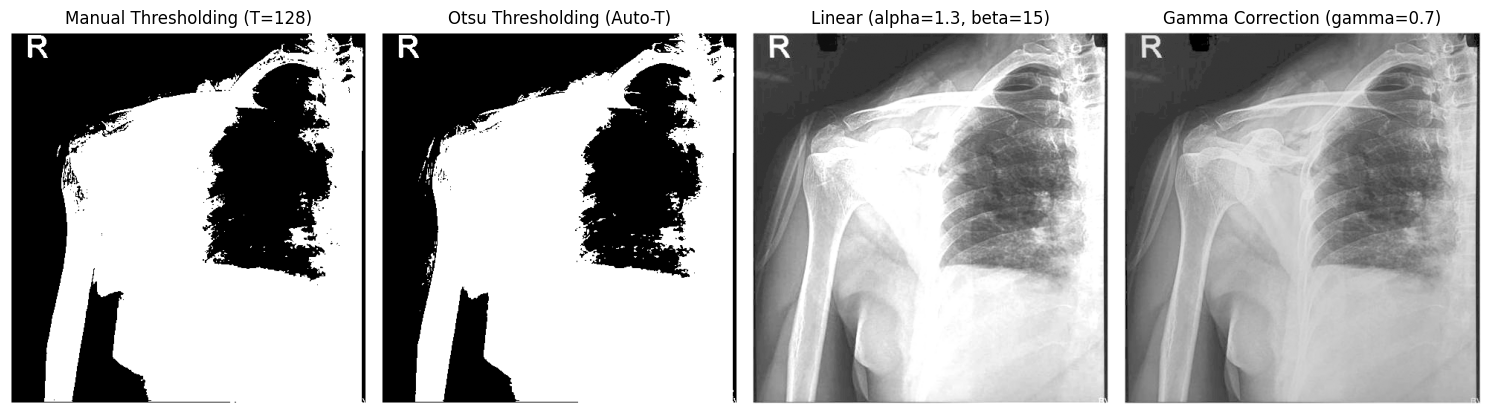

In [4]:
if img is not None:
    # 3.1 Manual Thresholding
    T = 128
    img_thr_np = np.where(img >= T, 255, 0).astype(np.uint8)
    _, img_thr_cv = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)
    
    # 3.2 Automatic Otsu Thresholding (OpenCV)
    _, img_otsu_cv = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 3.3 Linear Intensity Transform
    a, b = 1.3, 15
    img_lin_np = np.clip(a * img.astype(np.float32) + b, 0, 255).astype(np.uint8)
    img_lin_cv = cv2.convertScaleAbs(img, alpha=a, beta=b)
    
    # 3.4 Gamma Correction
    gamma = 0.7
    f = img.astype(np.float32) / 255.0
    img_gamma_np = (255.0 * np.power(f, gamma)).clip(0, 255).astype(np.uint8)
    
    print("Tổng hợp các biến đổi Pixel-wise:")
    show_multiple([img_thr_cv, img_otsu_cv, img_lin_cv, img_gamma_np],
                  ['Manual Thresholding (T=128)', 'Otsu Thresholding (Auto-T)',
                   'Linear (alpha=1.3, beta=15)', 'Gamma Correction (gamma=0.7)'], cols=4)


## 4. Bài tập thực hành tại lớp (Exercises)


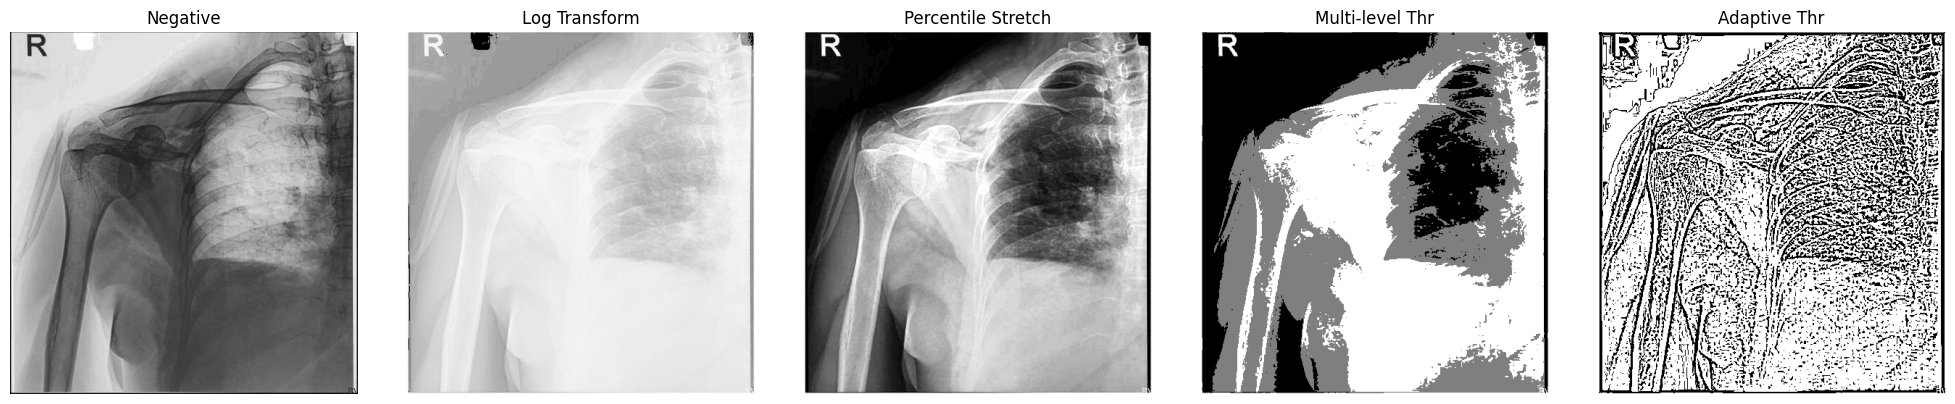

In [5]:
if img is not None:
    # Exercise A - Negative / Inversion (NumPy)
    img_neg = 255 - img
    
    # Exercise B - Log Transform (NumPy)
    c = 255.0 / np.log(1 + 255.0) # scaling const
    img_log = (c * np.log(1 + img.astype(np.float32))).clip(0, 255).astype(np.uint8)
    
    # Exercise C - Contrast Stretching (Percentile-based)
    p2 = np.percentile(img, 2)
    p98 = np.percentile(img, 98)
    img_stretch = (img.astype(np.float32) - p2) / (p98 - p2 + 1e-9)
    img_stretch = (255 * img_stretch).clip(0, 255).astype(np.uint8)
    
    # Exercise D - Multi-level Thresholding
    T1, T2 = 80, 160
    img_multi = np.zeros_like(img)
    img_multi[(img >= T1) & (img < T2)] = 127
    img_multi[img >= T2] = 255
    # (Pixels < T1 remain 0)
    
    # Exercise E - Adaptive Thresholding
    img_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    
    show_multiple([img_neg, img_log, img_stretch, img_multi, img_adapt],
                  ['Negative', 'Log Transform', 'Percentile Stretch', 'Multi-level Thr', 'Adaptive Thr'], cols=5, figsize=(20, 4))


## 5. Homeworks (Bài tập hoàn thành gửi chấm code)


--- Homework Results ---


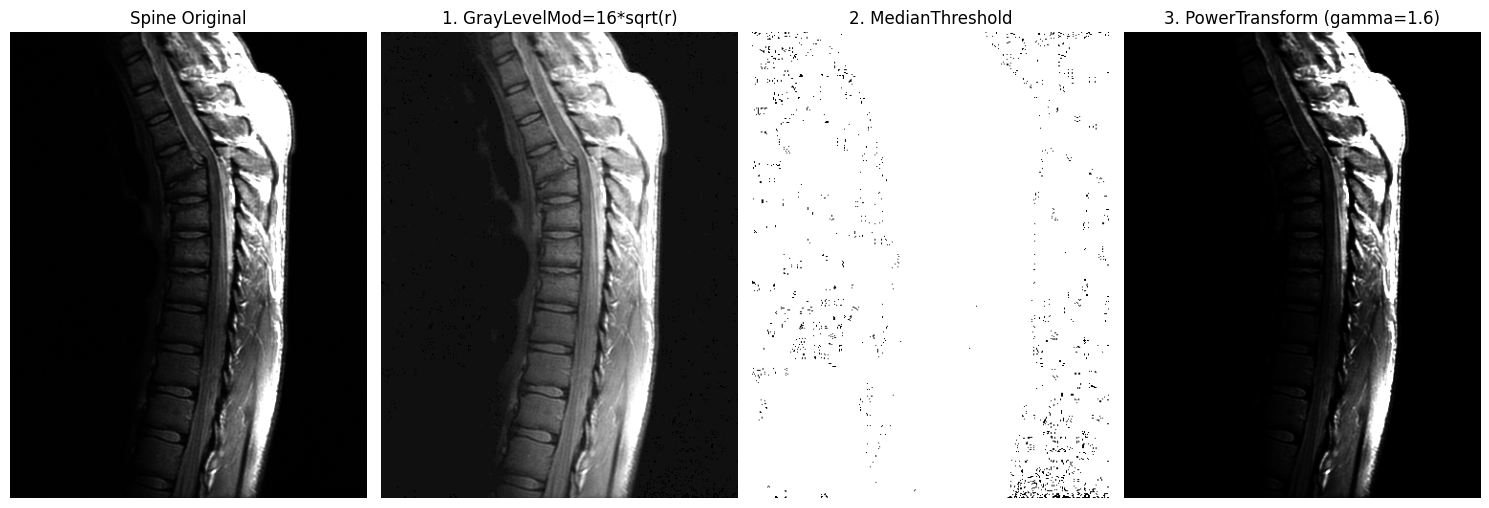

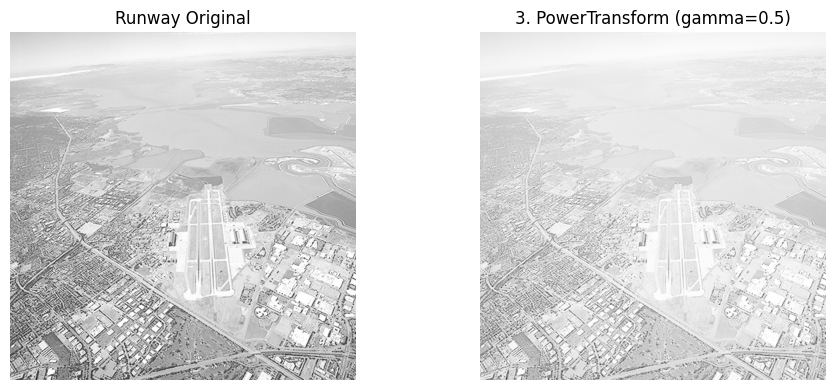

In [6]:
# Problem 1: GrayLevelModification
# s = 16 * sqrt(r)
def GrayLevelModification(image):
    s = 16.0 * np.sqrt(image.astype(np.float32))
    return np.clip(s, 0, 255).astype(np.uint8)

# Problem 2: MedianThreshold
# Thresholding strictly around Median intensity boundary
def MedianThreshold(image):
    m = np.median(image)
    return np.where(image >= m, 255, 0).astype(np.uint8)

# Problem 3: PowerTransform
# s = c * r^gamma
def PowerTransform(image, gamma, c=1.0):
    f = image.astype(np.float32) / 255.0
    s = c * np.power(f, gamma)
    return np.clip(s * 255.0, 0, 255).astype(np.uint8)

# --- Test Homework Implementations ---
img_spine = cv2.imread('../Resources/spine.jpg', cv2.IMREAD_GRAYSCALE)
img_runway = cv2.imread('../Resources/runway.jpg', cv2.IMREAD_GRAYSCALE)

if img_spine is not None and img_runway is not None:
    # Prob 1 applied on Spine
    spine_graymod = GrayLevelModification(img_spine)
    
    # Prob 2 applied on Spine
    spine_medianthr = MedianThreshold(img_spine)
    
    # Prob 3 applied on Runway and Spine
    gamma_runway = 0.5  # Dark features enhancement -> stretch darks towards brights
    gamma_spine = 1.6  # Tends to lower general brightness helping structures stand out
    
    runway_power = PowerTransform(img_runway, gamma=gamma_runway)
    spine_power = PowerTransform(img_spine, gamma=gamma_spine)
    
    print("--- Homework Results ---")
    show_multiple([img_spine, spine_graymod, spine_medianthr, spine_power],
                  ['Spine Original', '1. GrayLevelMod=16*sqrt(r)', '2. MedianThreshold', f'3. PowerTransform (gamma={gamma_spine})'], cols=4)
                  
    show_multiple([img_runway, runway_power],
                  ['Runway Original', f'3. PowerTransform (gamma={gamma_runway})'], cols=2, figsize=(10, 4))
